## Importing DataSet

In [1]:
!pip install opendatasets --quiet
import opendatasets as od
od.download('https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification')

Skipping, found downloaded files in "./bean-leaf-lesions-classification" (use force=True to force download)


## Importing Libraries

In [2]:
import torch
import torchvision
import torch.optim as optim
from torch.utils.data import DataLoader as dataloader
import torch.nn as nn
import torchvision.models as model
import torchvision.transforms as transform
import pandas as pd
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

## Setting-Up

In [3]:
print(torch.__version__)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

2.10.0+cu128


'cuda'

## Understanding Data

In [4]:
train_dataset = '/content/bean-leaf-lesions-classification/train'
test_dataset = '/content/bean-leaf-lesions-classification/val'
train_csv = '/content/bean-leaf-lesions-classification/train.csv'
test_csv = '/content/bean-leaf-lesions-classification/val.csv'
df = pd.read_csv(train_csv)
print('First five rows of training dataset\n')
print(df.head())
print('-----------------------------------------\n')
print('The distribution of classes of leaf\n')
print(df['category'].value_counts())
print('-----------------------------------------\n')
print('Total number of classes\n')
label = len(df['category'].unique())
print(label)
print('-----------------------------------------\n')
print('Shape of training dataset\n')
print(df.shape)
print('-----------------------------------------\n')
print('First five rows of testing dataset\n')
df_test = pd.read_csv(test_csv)
print(df_test.head())
print('-----------------------------------------\n')
print('Shape of testing dataset\n')
print(df_test.shape)

First five rows of training dataset

                            image:FILE  category
0   train/healthy/healthy_train.98.jpg         0
1  train/healthy/healthy_train.148.jpg         0
2  train/healthy/healthy_train.306.jpg         0
3  train/healthy/healthy_train.305.jpg         0
4   train/healthy/healthy_train.40.jpg         0
-----------------------------------------

The distribution of classes of leaf

category
2    348
1    345
0    341
Name: count, dtype: int64
-----------------------------------------

Total number of classes

3
-----------------------------------------

Shape of training dataset

(1034, 2)
-----------------------------------------

First five rows of testing dataset

                       image:FILE  category
0  val/healthy/healthy_val.25.jpg         0
1  val/healthy/healthy_val.32.jpg         0
2   val/healthy/healthy_val.3.jpg         0
3  val/healthy/healthy_val.16.jpg         0
4  val/healthy/healthy_val.10.jpg         0
----------------------------------

## Preprocessing

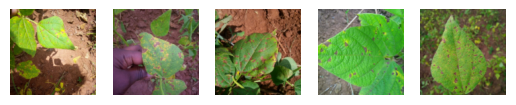

In [5]:
train_transform = transform.Compose([
    transform.Resize((128,128)),
    transform.ToTensor(),
])
test_transform = transform.Compose([
    transform.Resize((128,128)),
    transform.ToTensor(),
])

train_dataset = torchvision.datasets.ImageFolder(root=train_dataset,transform=train_transform)
test_dataset = torchvision.datasets.ImageFolder(root=test_dataset,transform=test_transform)

for i in range(0,5):
  plt.subplot(1,5,i+1)
  img_tensor = train_dataset[i][0]
   # Permute changes (C, H, W) to (H, W, C) directly
  plt.imshow(img_tensor.permute(1, 2, 0))
  plt.axis('off')

## Model-1

In [6]:
class CNN(nn.Module):
  def __init__(self,label):
    super().__init__()
    self.arch_1 = nn.Sequential(
        nn.Conv2d(in_channels=3,out_channels=16,kernel_size=3,padding=1),
        nn.ReLU(), nn.MaxPool2d(kernel_size=2,stride=2),
        nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3,padding=1),
        nn.ReLU(), nn.MaxPool2d(kernel_size=2,stride=2),
        nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,padding=1),
        nn.ReLU(), nn.MaxPool2d(kernel_size=2,stride=2),
        nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,padding=1),
        nn.ReLU(), nn.MaxPool2d(kernel_size=2,stride=2),
    )
    self.arch_2 = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=128*8*8,out_features=128),
        nn.ReLU(),
        nn.Linear(in_features=128,out_features=label),
    )
  def forward(self,x):
    x = self.arch_1(x)
    x = self.arch_2(x)
    return x

cnn = CNN(label).to(device)

In [7]:
train_dataloader = dataloader(train_dataset,batch_size=32,shuffle=True)
test_dataloader = dataloader(test_dataset,batch_size=32,shuffle=False)

cnn_train_accuracy_curve = []
cnn_train_loss_curve = []
cnn_test_accuracy_curve = []
cnn_test_loss_curve = []
epoch = 15

def train(model_used):
  loss = nn.CrossEntropyLoss()
  optimiser = optim.Adam(model_used.parameters(),lr=0.001)
  for epochs in range(epoch):
      model_used.train()
      train_accuracy = 0
      train_loss = 0
      for images,label in train_dataloader:
         images = images.to(device)
         label = label.to(device)
         optimiser.zero_grad()
         output = model_used(images)
         predictions = output.argmax(dim=1)
         accuracy = (predictions == label).float().mean().item()
         train_accuracy += accuracy
         loss_value = loss(output,label)
         train_loss += loss_value.item()
         loss_value.backward()
         optimiser.step()
      cnn_train_accuracy_curve.append(train_accuracy/len(train_dataloader))
      cnn_train_loss_curve.append(train_loss/len(train_dataloader))
      print(f'Epoch : {epochs+1}')
      print(f'Train Accuracy: {train_accuracy/len(train_dataloader)}')
      print(f'Train Loss: {train_loss/len(train_dataloader)}')
      model_used.eval()
      with torch.no_grad():
        test_accuracy = 0
        test_loss = 0
        for images, label in test_dataloader:
          images = images.to(device)
          label = label.to(device)
          output = model_used(images)
          predictions = output.argmax(dim=1)
          accuracy = (predictions == label).float().mean().item()
          test_accuracy += accuracy
          loss_value = loss(output,label)
          test_loss += loss_value.item()
        cnn_test_accuracy_curve.append(test_accuracy/len(test_dataloader))
        cnn_test_loss_curve.append(test_loss/len(test_dataloader))
        print(f'Test Accuracy: {test_accuracy/len(test_dataloader)}')
        print(f'Test Loss: {test_loss/len(test_dataloader)}')

train(model_used=cnn)

Epoch : 1
Train Accuracy: 0.37064393948424945
Train Loss: 1.0956914569392349
Test Accuracy: 0.48250000476837157
Test Loss: 1.0614470839500427
Epoch : 2
Train Accuracy: 0.5323863643588442
Train Loss: 0.9705230702053417
Test Accuracy: 0.675
Test Loss: 0.785895949602127
Epoch : 3
Train Accuracy: 0.6681818185430585
Train Loss: 0.7639406395680977
Test Accuracy: 0.6175000011920929
Test Loss: 0.9758400678634643
Epoch : 4
Train Accuracy: 0.6888257572145173
Train Loss: 0.7240449560411049
Test Accuracy: 0.6912500023841858
Test Loss: 0.6482873082160949
Epoch : 5
Train Accuracy: 0.7517045465382662
Train Loss: 0.6117213332291805
Test Accuracy: 0.78125
Test Loss: 0.5620764374732972
Epoch : 6
Train Accuracy: 0.7452651515151515
Train Loss: 0.5860282896143018
Test Accuracy: 0.7137500047683716
Test Loss: 0.6251389265060425
Epoch : 7
Train Accuracy: 0.7831439393939394
Train Loss: 0.5377271085074453
Test Accuracy: 0.7200000047683716
Test Loss: 0.576060152053833
Epoch : 8
Train Accuracy: 0.7842803037527836

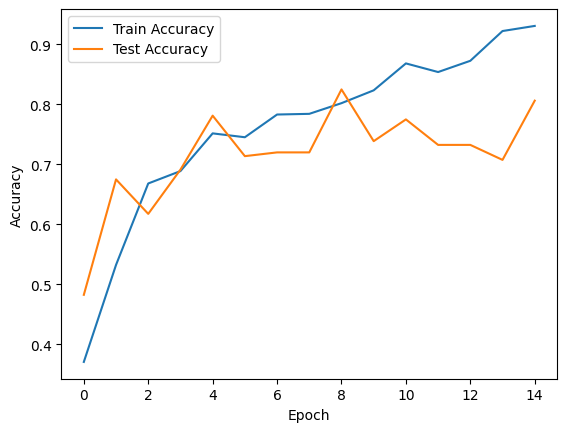

In [8]:
plt.plot(cnn_train_accuracy_curve,label='Train Accuracy')
plt.plot(cnn_test_accuracy_curve,label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

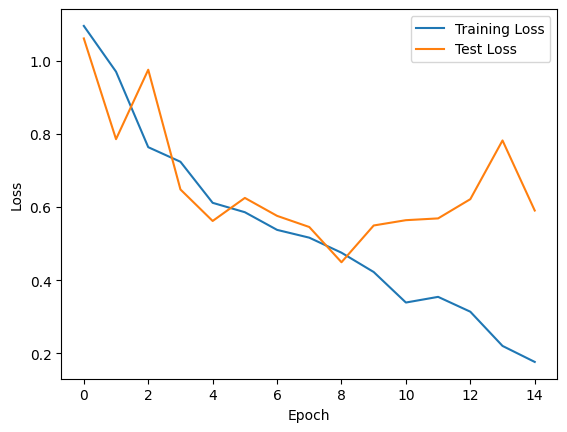

In [9]:
plt.plot(cnn_train_loss_curve,label='Training Loss')
plt.plot(cnn_test_loss_curve,label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Model-2

In [10]:
Googlenet = model.googlenet(weights='DEFAULT').to(device)
for parameters in Googlenet.parameters():
  parameters.requires_grad = True

Googlenet.fc

Googlenet.fc = nn.Linear(Googlenet.fc.in_features,label).to(device)

In [11]:
train_dataloader = dataloader(train_dataset,batch_size=32,shuffle=True)
test_dataloader = dataloader(test_dataset,batch_size=32,shuffle=False)

Googlenet_train_accuracy_curve = []
Googlenet_train_loss_curve = []
Googlenet_test_accuracy_curve = []
Googlenet_test_loss_curve = []


def train(model_used):
  loss = nn.CrossEntropyLoss()
  optimiser = optim.Adam(model_used.parameters(),lr=0.001)
  epoch = 15
  for epochs in range(epoch):
      model_used.train()
      train_accuracy = 0
      train_loss = 0
      for images,label in train_dataloader:
         images = images.to(device)
         label = label.to(device)
         optimiser.zero_grad()
         output = model_used(images)
         predictions = output.argmax(dim=1)
         accuracy = (predictions == label).float().mean().item()
         train_accuracy += accuracy
         loss_value = loss(output,label)
         train_loss += loss_value.item()
         loss_value.backward()
         optimiser.step()
      Googlenet_train_accuracy_curve.append(train_accuracy/len(train_dataloader))
      Googlenet_train_loss_curve.append(train_loss/len(train_dataloader))
      print(f'Epoch : {epochs+1}')
      print(f'Train Accuracy: {train_accuracy/len(train_dataloader)}')
      print(f'Train Loss: {train_loss/len(train_dataloader)}')
      model_used.eval()
      with torch.no_grad():
        test_accuracy = 0
        test_loss = 0
        for images, label in test_dataloader:
          images = images.to(device)
          label = label.to(device)
          output = model_used(images)
          predictions = output.argmax(dim=1)
          accuracy = (predictions == label).float().mean().item()
          test_accuracy += accuracy
          loss_value = loss(output,label)
          test_loss += loss_value.item()
        Googlenet_test_accuracy_curve.append(test_accuracy/len(test_dataloader))
        Googlenet_test_loss_curve.append(test_loss/len(test_dataloader))
        print(f'Test Accuracy: {test_accuracy/len(test_dataloader)}')
        print(f'Test Loss: {test_loss/len(test_dataloader)}')

train(model_used=Googlenet)

Epoch : 1
Train Accuracy: 0.7952651525988723
Train Loss: 0.4747865069093126
Test Accuracy: 0.8125
Test Loss: 0.6970963165411377
Epoch : 2
Train Accuracy: 0.9231060616897814
Train Loss: 0.19046433540907773
Test Accuracy: 0.8787500023841858
Test Loss: 0.36354057788848876
Epoch : 3
Train Accuracy: 0.974242425326145
Train Loss: 0.06937387647728126
Test Accuracy: 0.9625
Test Loss: 0.09652760149911047
Epoch : 4
Train Accuracy: 0.9725378787878788
Train Loss: 0.0781235753586798
Test Accuracy: 0.94375
Test Loss: 0.19048924148082733
Epoch : 5
Train Accuracy: 0.9770833344170542
Train Loss: 0.07456046881182402
Test Accuracy: 0.95625
Test Loss: 0.09509076797403396
Epoch : 6
Train Accuracy: 0.978219696969697
Train Loss: 0.06204301838509061
Test Accuracy: 0.95625
Test Loss: 0.11062876653741113
Epoch : 7
Train Accuracy: 0.974242425326145
Train Loss: 0.06588868573872429
Test Accuracy: 0.8450000047683716
Test Loss: 0.6050953842699528
Epoch : 8
Train Accuracy: 0.9626893943006342
Train Loss: 0.13717693022

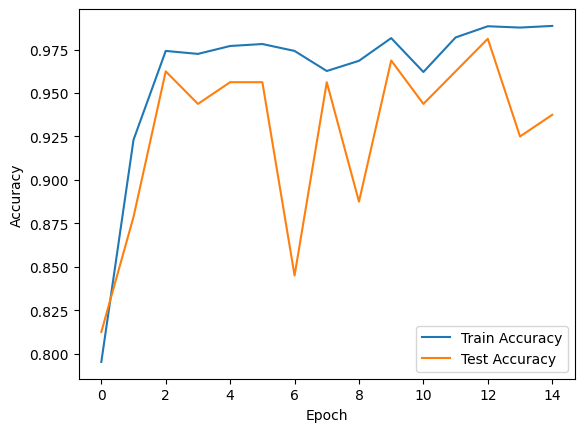

In [12]:
plt.plot(Googlenet_train_accuracy_curve,label='Train Accuracy')
plt.plot(Googlenet_test_accuracy_curve,label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

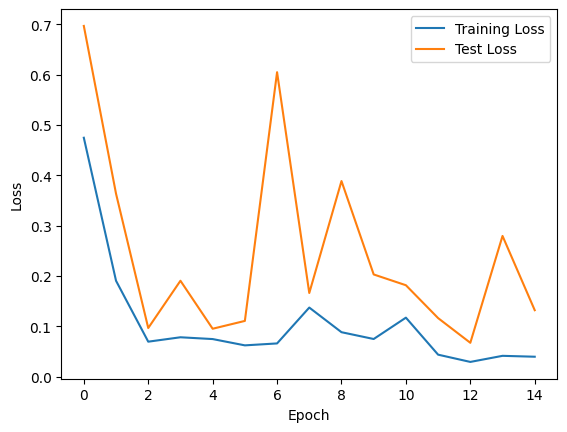

In [13]:
plt.plot(Googlenet_train_loss_curve,label='Training Loss')
plt.plot(Googlenet_test_loss_curve,label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Model - 3

In [14]:
googlenet = model.googlenet(weights='DEFAULT').to(device)
for parameters in googlenet.parameters():
  parameters.requires_grad = False
googlenet.fc = nn.Linear(googlenet.fc.in_features,label).to(device)

In [15]:
train_dataloader = dataloader(train_dataset,batch_size=32,shuffle=True)
test_dataloader = dataloader(test_dataset,batch_size=32,shuffle=False)

googlenet_train_accuracy_curve = []
googlenet_train_loss_curve = []
googlenet_test_accuracy_curve = []
googlenet_test_loss_curve = []


def train(model_used):
  loss = nn.CrossEntropyLoss()
  optimiser = optim.Adam(model_used.parameters(),lr=0.001)
  epoch = 15
  for epochs in range(epoch):
      model_used.train()
      train_accuracy = 0
      train_loss = 0
      for images,label in train_dataloader:
         images = images.to(device)
         label = label.to(device)
         optimiser.zero_grad()
         output = model_used(images)
         predictions = output.argmax(dim=1)
         accuracy = (predictions == label).float().mean().item()
         train_accuracy += accuracy
         loss_value = loss(output,label)
         train_loss += loss_value.item()
         loss_value.backward()
         optimiser.step()
      googlenet_train_accuracy_curve.append(train_accuracy/len(train_dataloader))
      googlenet_train_loss_curve.append(train_loss/len(train_dataloader))
      print(f'Epoch : {epochs+1}')
      print(f'Train Accuracy: {train_accuracy/len(train_dataloader)}')
      print(f'Train Loss: {train_loss/len(train_dataloader)}')
      model_used.eval()
      with torch.no_grad():
        test_accuracy = 0
        test_loss = 0
        for images, label in test_dataloader:
          images = images.to(device)
          label = label.to(device)
          output = model_used(images)
          predictions = output.argmax(dim=1)
          accuracy = (predictions == label).float().mean().item()
          test_accuracy += accuracy
          loss_value = loss(output,label)
          test_loss += loss_value.item()
        googlenet_test_accuracy_curve.append(test_accuracy/len(test_dataloader))
        googlenet_test_loss_curve.append(test_loss/len(test_dataloader))
        print(f'Test Accuracy: {test_accuracy/len(test_dataloader)}')
        print(f'Test Loss: {test_loss/len(test_dataloader)}')

train(model_used=googlenet)

Epoch : 1
Train Accuracy: 0.6125000010837208
Train Loss: 0.8943250612779097
Test Accuracy: 0.7850000023841858
Test Loss: 0.6556642591953278
Epoch : 2
Train Accuracy: 0.7293560613285411
Train Loss: 0.6649202370282375
Test Accuracy: 0.8375
Test Loss: 0.5149493843317032
Epoch : 3
Train Accuracy: 0.7964015151515151
Train Loss: 0.562946027878559
Test Accuracy: 0.8375
Test Loss: 0.4750512808561325
Epoch : 4
Train Accuracy: 0.7886363647200845
Train Loss: 0.539151643261765
Test Accuracy: 0.81875
Test Loss: 0.4634201109409332
Epoch : 5
Train Accuracy: 0.8117424249649048
Train Loss: 0.49357100508429785
Test Accuracy: 0.825
Test Loss: 0.4353907644748688
Epoch : 6
Train Accuracy: 0.8407196980534177
Train Loss: 0.4464948655981006
Test Accuracy: 0.825
Test Loss: 0.41077429205179217
Epoch : 7
Train Accuracy: 0.8261363632751234
Train Loss: 0.46604732672373456
Test Accuracy: 0.8375
Test Loss: 0.40020083636045456
Epoch : 8
Train Accuracy: 0.8640151511539113
Train Loss: 0.40499560580109106
Test Accuracy:

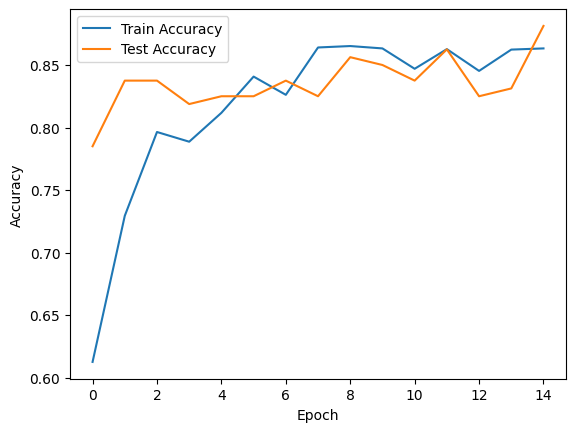

In [16]:
plt.plot(googlenet_train_accuracy_curve,label='Train Accuracy')
plt.plot(googlenet_test_accuracy_curve,label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

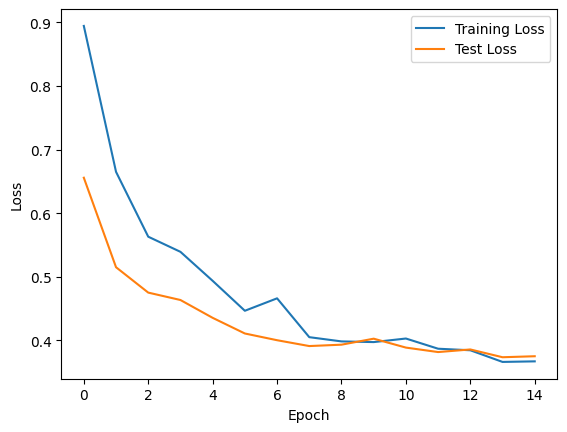

In [17]:
plt.plot(googlenet_train_loss_curve,label='Training Loss')
plt.plot(googlenet_test_loss_curve,label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Conclusion

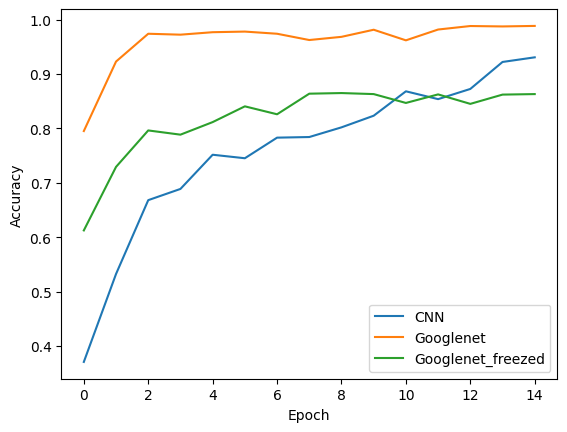

In [18]:
plt.plot(cnn_train_accuracy_curve,label='CNN')
plt.plot(Googlenet_train_accuracy_curve,label='Googlenet')
plt.plot(googlenet_train_accuracy_curve,label='Googlenet_freezed')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

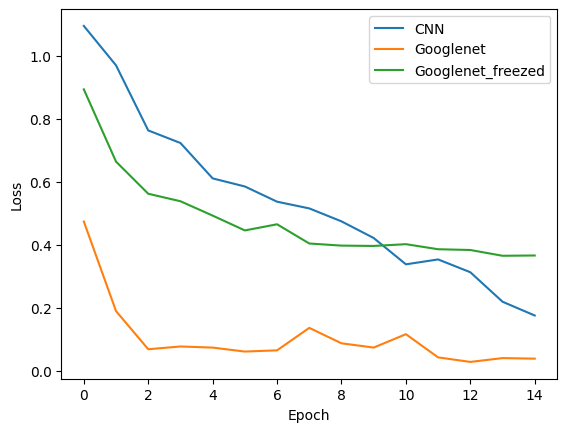

In [19]:
plt.plot(cnn_train_loss_curve,label='CNN')
plt.plot(Googlenet_train_loss_curve,label='Googlenet')
plt.plot(googlenet_train_loss_curve,label='Googlenet_freezed')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

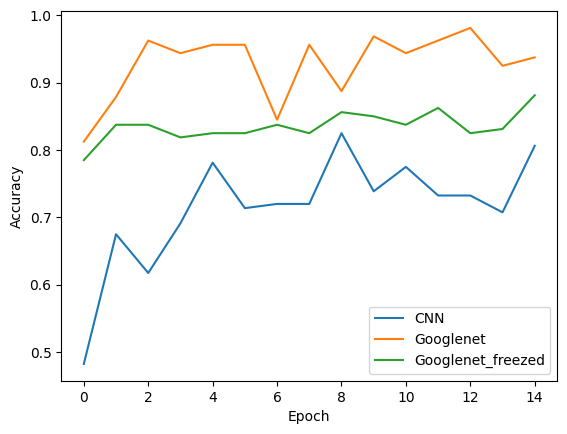

In [20]:
plt.plot(cnn_test_accuracy_curve,label='CNN')
plt.plot(Googlenet_test_accuracy_curve,label='Googlenet')
plt.plot(googlenet_test_accuracy_curve,label='Googlenet_freezed')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

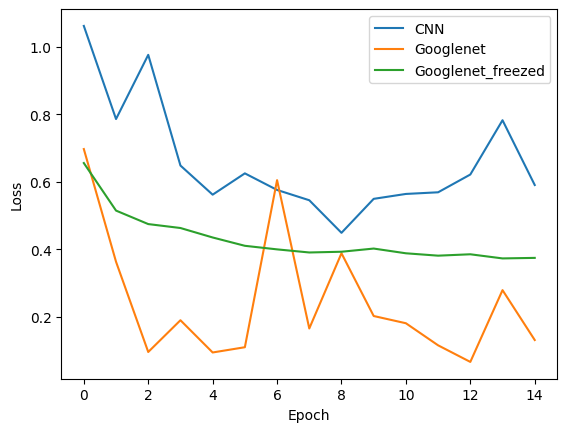

In [21]:
plt.plot(cnn_test_loss_curve,label='CNN')
plt.plot(Googlenet_test_loss_curve,label='Googlenet')
plt.plot(googlenet_test_loss_curve,label='Googlenet_freezed')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()